# IEMOCAP Base downstream training

## 1. 目的と注意事項

固定した emotion2vec Base encoder で発話ごとの特徴を抽出し、下流分類器だけを学習します。短縮学習は、性能の高さではなく、学習・保存・held-out Session評価・再読込が完走するかを確認するものです。研究用の数値は、短縮学習成功後の5-fold実験で取得します。

実データ、パス、発話ID、個別ラベル、個別予測、実行済みNotebookはCodexやGitへ渡しません。共有対象は集計JSONとグラフだけです。emotion2vecの下流評価方針は[原論文](https://arxiv.org/abs/2312.15185)を参照してください。

## 2. 設定

実データの場所は環境変数だけから取得します。`demo` は合成特徴、`private` は利用者の非公開環境でのみ実行します。

In [1]:
import json, os, re, sys
from dataclasses import asdict
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'iemocap_downstream').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from iemocap_downstream.notebook_pipeline import (
    TrainingConfig, environment_summary, generate_private_manifest_and_labels,
    load_private_feature_bundle, make_demo_bundle, make_session_loaders,
    plot_training_history, private_paths_from_env, reload_and_evaluate,
    run_five_fold, run_one_fold, run_private_feature_extraction,
    validate_feature_bundle,
)

MODE = os.environ.get('IEMOCAP_NOTEBOOK_MODE', 'demo').lower()
if MODE not in {'demo', 'private'}:
    raise ValueError('IEMOCAP_NOTEBOOK_MODE must be demo or private')
CONFIG = TrainingConfig(
    seed=int(os.environ.get('IEMOCAP_SEED', '42')),
    device=os.environ.get('IEMOCAP_DEVICE', 'auto'),
    epochs=int(os.environ.get('IEMOCAP_EPOCHS', '1')),
    batch_size=int(os.environ.get('IEMOCAP_BATCH_SIZE', '8')),
    test_session=int(os.environ.get('IEMOCAP_TEST_SESSION', '5')),
)
ARTIFACT_DIR = PROJECT_ROOT / 'runs' / 'iemocap_base_downstream'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
SAFE_OUTPUTS = [{'mode': MODE, 'seed': CONFIG.seed, 'device': CONFIG.device, 'epochs': CONFIG.epochs, 'batch_size': CONFIG.batch_size, 'test_session': CONFIG.test_session}]
SAFE_OUTPUTS[-1]

{'mode': 'demo',
 'seed': 42,
 'device': 'auto',
 'epochs': 1,
 'batch_size': 8,
 'test_session': 5}

## 3. 環境確認

Python、PyTorch、fairseq、checkpoint、CPU/CUDAの可否だけを確認します。パスは表示しません。

In [2]:
private_paths = private_paths_from_env() if MODE == 'private' else None
env_status = environment_summary(MODE, private_paths)
SAFE_OUTPUTS.append(env_status)
env_status

{'python': '3.12.13',
 'pytorch': '2.12.0+cpu',
 'fairseq_available': False,
 'cuda_available': False,
 'mode': 'demo'}

## 4. manifest・標準4感情ラベル生成

`private` では利用者が `IEMOCAP_RUN_PREP=1` を指定した場合だけ生成します。Notebookには合否と集計件数だけを表示します。

In [3]:
if MODE == 'demo':
    prep_status = {'status': 'not_required_in_demo'}
elif os.environ.get('IEMOCAP_RUN_PREP') == '1':
    prep_status = generate_private_manifest_and_labels(private_paths)
else:
    prep_status = {'status': 'skipped_existing_private_artifacts'}
SAFE_OUTPUTS.append(prep_status)
prep_status

{'status': 'not_required_in_demo'}

## 5. Base特徴抽出

encoderは`eval()`と`torch.no_grad()`で固定されます。`--device {auto,cpu,cuda}`で実行先を選び、encoderの重みは分類器optimizerへ渡しません。`private`で抽出する場合だけ `IEMOCAP_RUN_EXTRACT=1` を指定します。

In [4]:
if MODE == 'demo':
    bundle = make_demo_bundle(seed=CONFIG.seed)
    extraction_status = {'status': 'passed', 'source': 'synthetic_fixed_features'}
else:
    if os.environ.get('IEMOCAP_RUN_EXTRACT') == '1':
        extraction_status = run_private_feature_extraction(private_paths, PROJECT_ROOT, CONFIG.device)
    else:
        extraction_status = {'status': 'skipped_existing_private_features'}
    bundle = load_private_feature_bundle(private_paths.work_dir / 'train')
SAFE_OUTPUTS.append(extraction_status)
extraction_status

{'status': 'passed', 'source': 'synthetic_fixed_features'}

## 6. 集計値による検証

特徴次元、有限値、フレーム合計、ラベル行数、Session 1〜5の存在だけを表示します。

In [5]:
feature_summary = validate_feature_bundle(bundle, expected_input_dim=16 if MODE == 'demo' else 768)
SAFE_OUTPUTS.append(feature_summary)
feature_summary

{'status': 'passed',
 'feature_dim': 16,
 'finite_features': True,
 'total_frames': 278,
 'label_rows': 60,
 'sessions_present': [1, 2, 3, 4, 5]}

## 7. 短縮学習

既定は1 epochです。validationとtestを横に並べ、loss、WA、UA、macro F1の差を指標ごとに比較します。

In [6]:
checkpoint_path = ARTIFACT_DIR / 'short_run_classifier.pt'
short_result = run_one_fold(bundle, CONFIG, checkpoint_path)
short_summary = {
    'status': short_result['status'],
    'train_loss': short_result['history'][-1]['train_loss'],
    **short_result['test_metrics'],
    'optimizer_updated': short_result['optimizer_updated'],
}
SAFE_OUTPUTS.append(short_summary)
validation_test_table = pd.DataFrame({
    'validation': short_result['split_metrics']['validation'],
    'test': short_result['split_metrics']['test'],
}).loc[['loss', 'wa', 'ua', 'macro_f1']]
validation_test_table.index.name = 'metric'
validation_test_table.columns.name = 'split'
display(validation_test_table.round(4))

split     validation     test
metric                       
loss          1.2027   1.2043
wa           91.6667  83.3333
ua           91.6667  83.3333
macro_f1     91.4286  81.2500

## 8. 学習経過の可視化

epoch別lossと検証指標だけを描画します。個別予測や音声は扱いません。

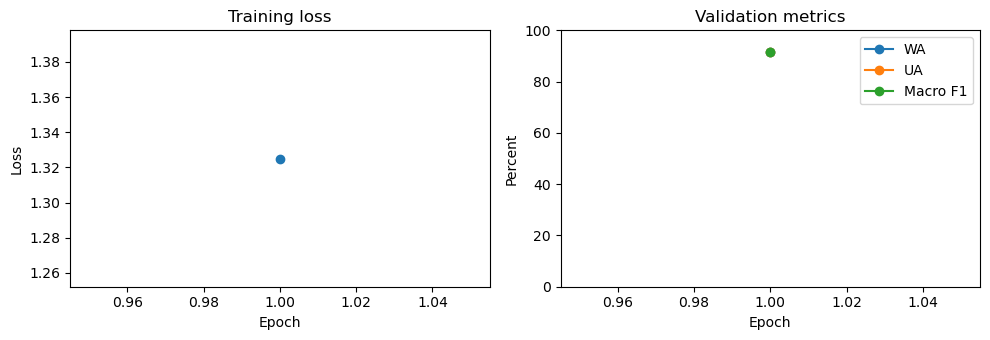

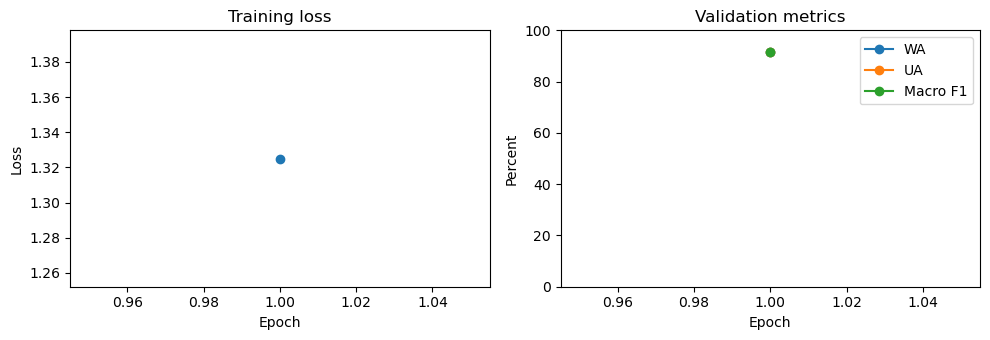

In [7]:
figure = plot_training_history(short_result['history'], ARTIFACT_DIR / 'short_run_history.png')
figure

## 9. checkpoint再検証

保存した分類器を再読込し、同じheld-out Sessionを評価します。metadataにはencoder ID、入力次元、class labels、seed、test sessionを保存します。

In [8]:
loaders, _ = make_session_loaders(bundle, CONFIG)
_, checkpoint_metadata, reload_metrics = reload_and_evaluate(checkpoint_path, loaders['test'], CONFIG.device if CONFIG.device != 'auto' else ('cuda' if env_status['cuda_available'] else 'cpu'))
reload_summary = {'status': 'passed', 'metrics': reload_metrics, 'metadata': checkpoint_metadata}
SAFE_OUTPUTS.append(reload_summary)
final_validation_test_table = pd.DataFrame({
    'validation': short_result['split_metrics']['validation'],
    'test': reload_metrics,
}).loc[['loss', 'wa', 'ua', 'macro_f1']]
final_validation_test_table.index.name = 'metric'
final_validation_test_table.columns.name = 'split'
display(final_validation_test_table.round(4))

split     validation     test
metric                       
loss          1.2027   1.2043
wa           91.6667  83.3333
ua           91.6667  83.3333
macro_f1     91.4286  81.2500

## 10. 5-fold Base基準実験

短縮学習が成功した後だけ実行します。`demo`では導線確認のため実行し、`private`では `IEMOCAP_RUN_FIVE_FOLD=1` のときだけ実行します。fold別と平均のWA、UA、macro F1をJSONへ保存します。

In [9]:
run_full = short_result['status'] == 'passed' and (MODE == 'demo' or os.environ.get('IEMOCAP_RUN_FIVE_FOLD') == '1')
if run_full:
    fold_summary = run_five_fold(bundle, CONFIG, ARTIFACT_DIR / 'five_fold')
else:
    fold_summary = {'status': 'skipped_until_explicit_private_opt_in'}
SAFE_OUTPUTS.append(fold_summary)
fold_summary

{'status': 'passed',
 'folds': [{'test_session': 1,
   'wa': 91.66666666666666,
   'ua': 91.66666666666666,
   'macro_f1': 91.42857142857143},
  {'test_session': 2, 'wa': 75.0, 'ua': 75.0, 'macro_f1': 65.17857142857142},
  {'test_session': 3, 'wa': 75.0, 'ua': 75.0, 'macro_f1': 66.66666666666666},
  {'test_session': 4,
   'wa': 83.33333333333334,
   'ua': 83.33333333333333,
   'macro_f1': 81.25},
  {'test_session': 5,
   'wa': 83.33333333333334,
   'ua': 83.33333333333333,
   'macro_f1': 81.25}],
 'average': {'wa': 81.66666666666667,
  'ua': 81.66666666666666,
  'macro_f1': 77.1547619047619}}

## 出力プライバシー確認と次の判断

表示した構造化出力に、環境変数の実値やIEMOCAP発話ID形式が混入していないことを確認します。demo完走後、利用者側の非公開環境で短縮学習へ進みます。VAD媒介型・Large・Base/Large比較は5-fold Base基準実験の後です。

In [10]:
serialized = json.dumps(SAFE_OUTPUTS, ensure_ascii=False)
private_values = [os.environ.get(name, '') for name in ('IEMOCAP_ROOT', 'IEMOCAP_WORK_DIR', 'EMOTION2VEC_CHECKPOINT', 'EMOTION2VEC_USER_DIR')]
contains_private_value = any(value and value in serialized for value in private_values)
contains_utterance_id = bool(re.search(r'Ses0[1-5][FM]?_', serialized))
privacy_status = {'status': 'passed' if not contains_private_value and not contains_utterance_id else 'failed', 'checked_outputs': len(SAFE_OUTPUTS)}
if privacy_status['status'] != 'passed':
    raise RuntimeError('privacy audit failed')
privacy_status

{'status': 'passed', 'checked_outputs': 8}